# Cats vs Dogs Binary Image Classification with CNN

## Complete Production-Ready Deep Learning Pipeline

This notebook takes you from raw image data → trained CNN model → evaluation → deployment-ready application.

**Goals:**
- Build and train a CNN to classify images of cats and dogs
- Evaluate model performance
- Save the trained model
- Prepare for deployment


## 1. Setup & Imports

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import kagglehub

## 2. Set Configuration Parameters

In [ ]:
# Configuration
CONFIG = {
    'dataset_path': '',
    'image_size': (128, 128),
    'batch_size': 32,
    'epochs': 5,
    'validation_split': 0.2,
    'seed': 42,
    'model_save_path': './models/cats_dogs_cnn_model.h5',
    'model_save_path_keras': './models/cats_dogs_cnn_model.keras'
}

# Download dataset using kagglehub
print("Downloading dataset...")
# The dataset_download returns the path to the extracted dataset
downloaded_dataset_path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
CONFIG['dataset_path'] = os.path.join(str(downloaded_dataset_path), 'PetImages')
print(f"Dataset downloaded and extracted to: {CONFIG['dataset_path']}")

# Create model directory
os.makedirs(os.path.dirname(CONFIG['model_save_path']), exist_ok=True)

# Set random seeds for reproducibility
np.random.seed(CONFIG['seed'])
tf.random.set_seed(CONFIG['seed'])

print("Configuration set:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Dataset downloaded and extracted to: /kaggle/input/dog-and-cat-classification-dataset/PetImages
Configuration set:
  dataset_path: /kaggle/input/dog-and-cat-classification-dataset/PetImages
  image_size: (128, 128)
  batch_size: 32
  epochs: 5
  validation_split: 0.2
  seed: 42
  model_save_path: ./models/cats_dogs_cnn_model.h5
  model_save_path_keras: ./models/cats_dogs_cnn_model.keras


## 3. Data Exploration & Validation

In [ ]:
# Check dataset structure
dataset_path = CONFIG['dataset_path']

if os.path.exists(dataset_path):
    cats_dir = os.path.join(dataset_path, 'cats')
    dogs_dir = os.path.join(dataset_path, 'dogs')

    if os.path.exists(cats_dir) and os.path.exists(dogs_dir):
        cats_count = len([f for f in os.listdir(cats_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        dogs_count = len([f for f in os.listdir(dogs_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])

        print(f"Dataset Found!")
        print(f"  Cats images: {cats_count}")
        print(f"  Dogs images: {dogs_count}")
        print(f"  Total images: {cats_count + dogs_count}")
    else:
        print("⚠️  Dataset structure not found. Expected:")
        print("   ./dataset/cats/")
        print("   ./dataset/dogs/")
else:
    print("⚠️  Dataset directory not found at:", dataset_path)
    print("\nPlease ensure your dataset is organized as:")
    print("  dataset/")
    print("    cats/  (cat images)")
    print("    dogs/  (dog images)")

⚠️  Dataset structure not found. Expected:
   ./dataset/cats/
   ./dataset/dogs/


## 4. Data Loading & Preprocessing

In [ ]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=CONFIG['validation_split'],
    fill_mode='nearest'
)

# Test/validation data (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_data = train_datagen.flow_from_directory(
    CONFIG['dataset_path'],
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='training',
    seed=CONFIG['seed']
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    CONFIG['dataset_path'],
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='validation',
    seed=CONFIG['seed']
)

print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Classes: {train_data.class_indices}")

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Training samples: 20000
Validation samples: 4998
Classes: {'Cat': 0, 'Dog': 1}


## 5. Visualize Sample Data

Sample training images:


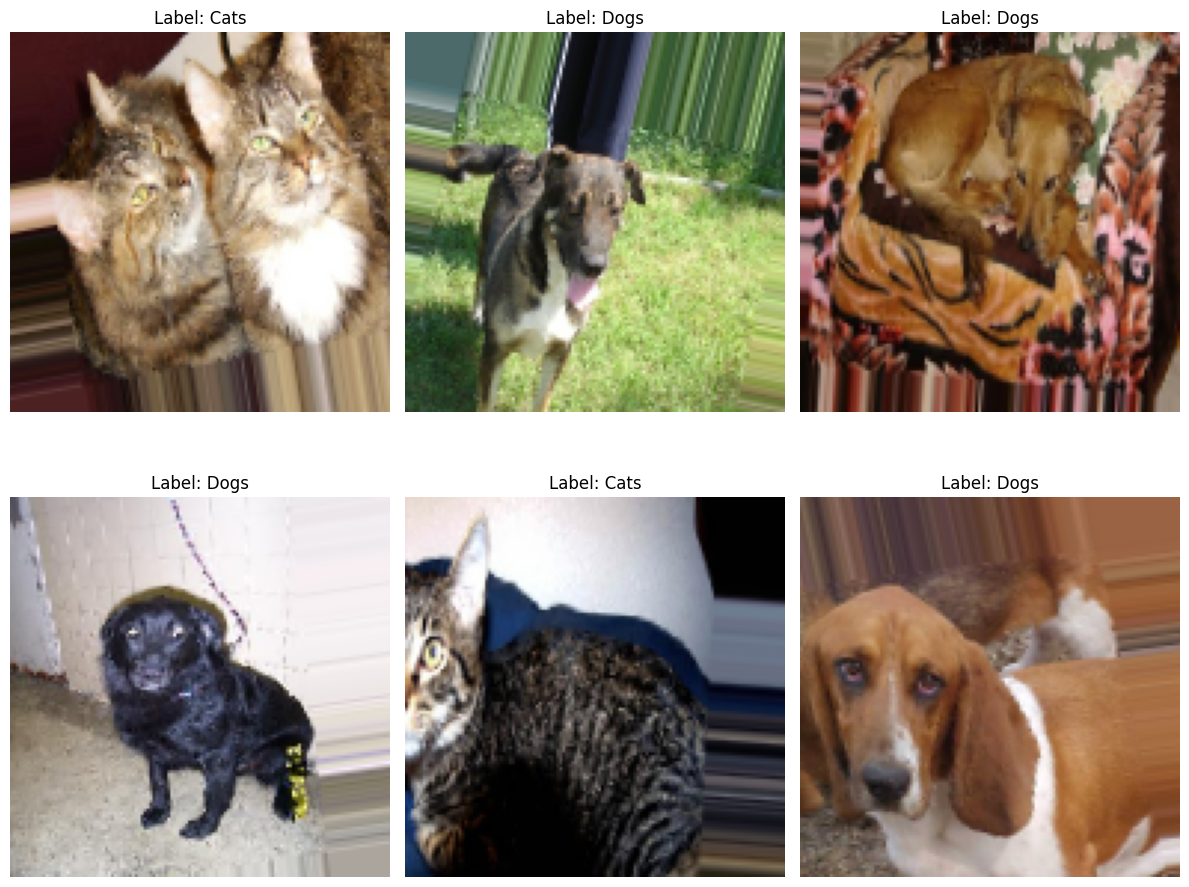

In [ ]:
# Visualize sample images from training data
def plot_sample_images(data_generator, num_samples=6):
    images, labels = next(iter(data_generator))

    fig, axes = plt.subplots(2, 3, figsize=(12, 10))
    axes = axes.flatten()

    class_names = ['Cats', 'Dogs']

    for i in range(min(num_samples, len(images))):
        axes[i].imshow(images[i])
        axes[i].set_title(f"Label: {class_names[int(labels[i])]}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("Sample training images:")
plot_sample_images(train_data)

## 6. Build CNN Model

In [ ]:
# Build the CNN model
def create_cnn_model(input_shape=(128, 128, 3)):
    """
    Create a simple but effective CNN for binary image classification.

    Architecture:
    - Conv2D layers with ReLU activation for feature extraction
    - MaxPooling layers for dimensionality reduction
    - Dropout layers for regularization
    - Dense layers for classification
    """
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        # Output layer (binary classification)
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Create model
model = create_cnn_model()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,057 (24.98 MB)

 Trainable params: 6,549,057 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

In [ ]:
print("Starting training...\n")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=CONFIG['epochs'],
    verbose=1,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data)
)

print("\nTraining completed!")

Starting training...

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 392ms/step - accuracy: 0.5337 - loss: 0.6873 - val_accuracy: 0.5960 - val_loss: 0.6642
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.5526 - loss: 0.6781 - val_accuracy: 0.5704 - val_loss: 0.6795
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.5709 - loss: 0.6792 - val_accuracy: 0.5758 - val_loss: 0.6755
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.5781 - loss: 0.6761 - val_accuracy: 0.5998 - val_loss: 0.6579
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.6248 - loss: 0.6486 - val_accuracy: 0.6619 - val_loss: 0.6292

Training completed!


## 8. Visualize Training History

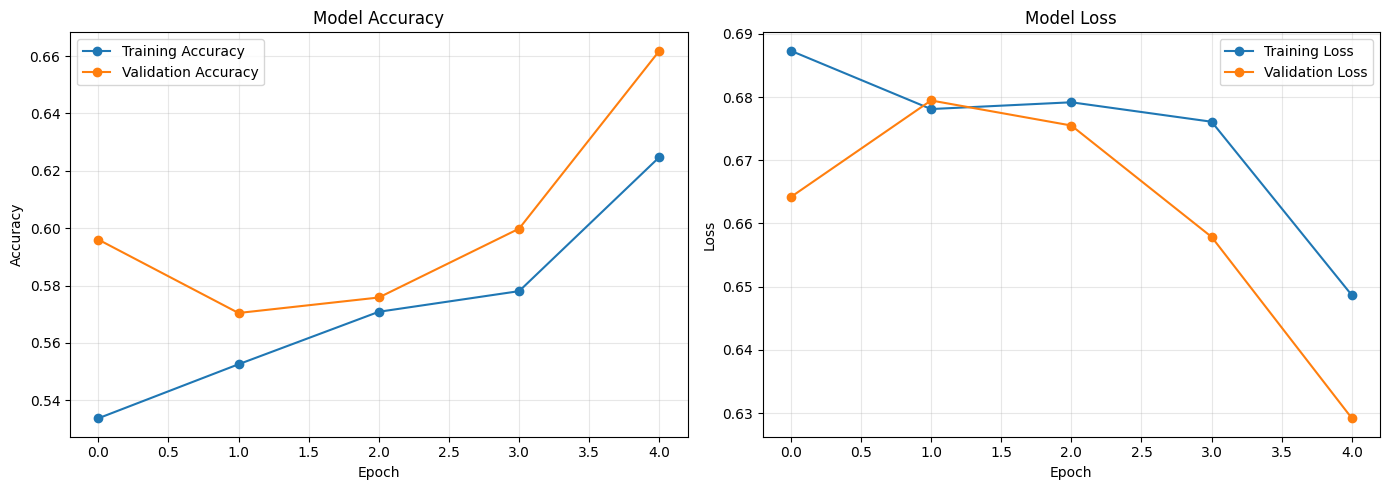

Final Training Accuracy: 0.6248
Final Validation Accuracy: 0.6619


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 9. Model Evaluation

In [ ]:
# Evaluate model on validation data
val_loss, val_accuracy = model.evaluate(val_data)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Get predictions on validation set
val_data.reset()
y_pred_proba = model.predict(val_data)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = val_data.classes[:len(y_pred)]

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Cats', 'Dogs']))

157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 216ms/step - accuracy: 0.6553 - loss: 0.6263
Validation Loss: 0.6263
Validation Accuracy: 0.6553
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 201ms/step

Classification Report:
              precision    recall  f1-score   support

        Cats       0.49      0.59      0.54      2499
        Dogs       0.49      0.39      0.44      2499

    accuracy                           0.49      4998
   macro avg       0.49      0.49      0.49      4998
weighted avg       0.49      0.49      0.49      4998



## 10. Confusion Matrix

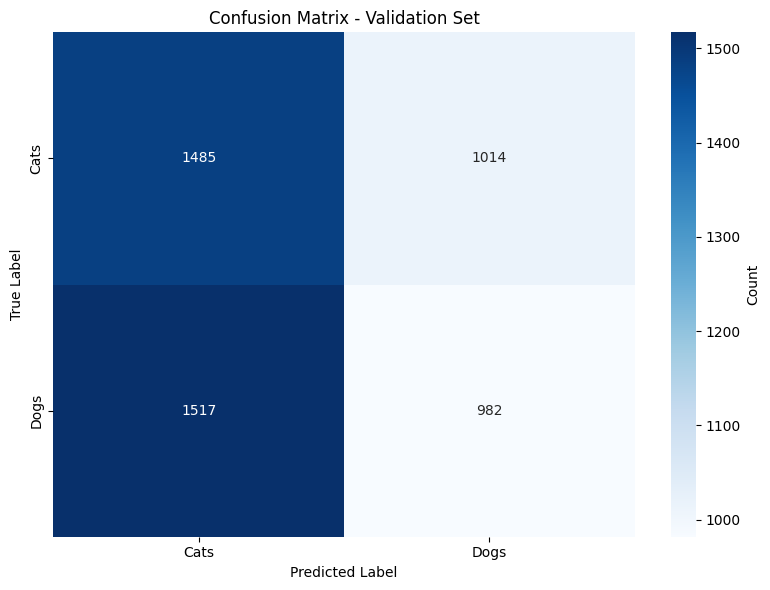


True Negatives (Correct Cats): 1485
False Positives (Cats→Dogs): 1014
False Negatives (Dogs→Cats): 1517
True Positives (Correct Dogs): 982


In [ ]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cats', 'Dogs'],
            yticklabels=['Cats', 'Dogs'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Correct Cats): {cm[0, 0]}")
print(f"False Positives (Cats→Dogs): {cm[0, 1]}")
print(f"False Negatives (Dogs→Cats): {cm[1, 0]}")
print(f"True Positives (Correct Dogs): {cm[1, 1]}")

## 11. Save the Trained Model

In [ ]:
# Save model in both formats for compatibility
model.save(CONFIG['model_save_path'])
model.save(CONFIG['model_save_path_keras'])

print(f"✓ Model saved to: {CONFIG['model_save_path']}")
print(f"✓ Model saved to: {CONFIG['model_save_path_keras']}")

# Display model info
print(f"\nModel Info:")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  Input Shape: {model.input_shape}")
print(f"  Output Shape: {model.output_shape}")

✓ Model saved to: ./models/cats_dogs_cnn_model.h5
✓ Model saved to: ./models/cats_dogs_cnn_model.keras

Model Info:
  Total Parameters: 6,549,057
  Input Shape: (None, 128, 128, 3)
  Output Shape: (None, 1)
